Mounted at /content/drive


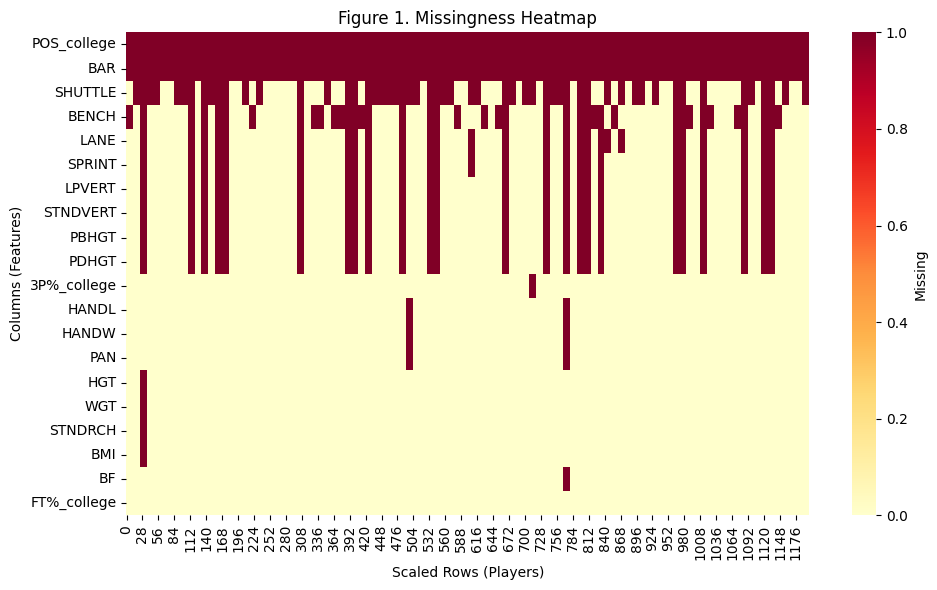

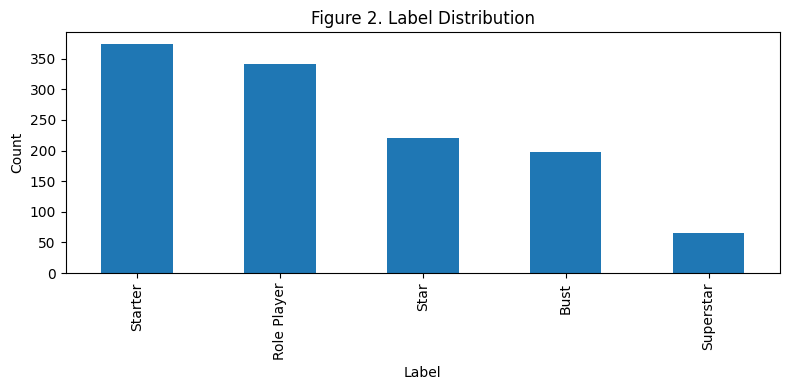

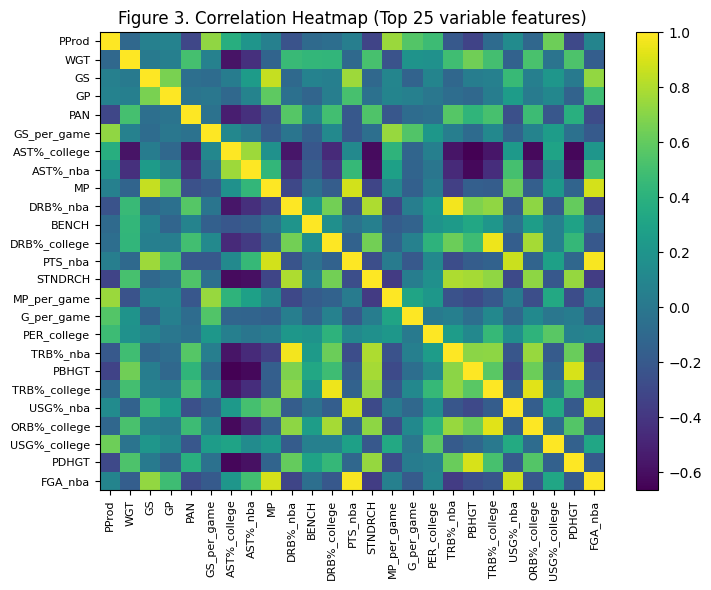

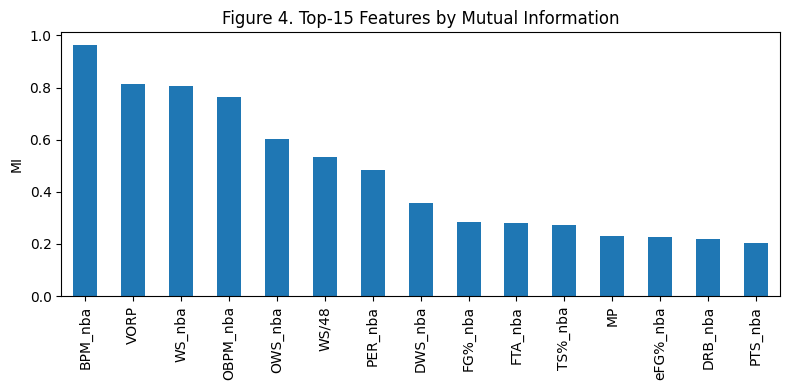

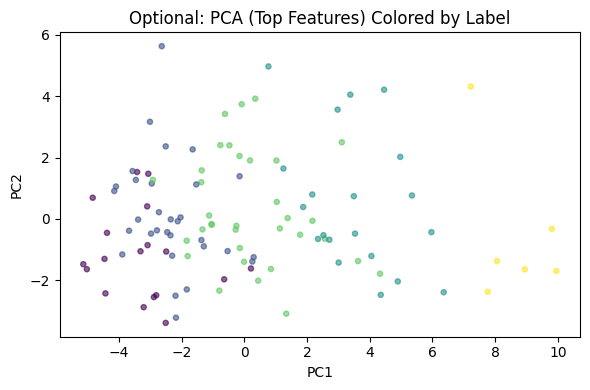

EDA complete. Saved CSVs to: /content/drive/MyDrive/nba-draft-sucess/final_master


In [2]:
# === Setup ===
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA

# For VIF
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- Google Drive (Colab) ---
if os.path.exists("/content/drive"):
    try:
        !fusermount -u /content/drive 2>/dev/null
        !rm -rf /content/drive
    except Exception as e:
        print("Unmount warning:", e)
from google.colab import drive
drive.mount('/content/drive')

plt.rcParams["figure.figsize"] = (8, 4)
pd.set_option("display.max_columns", None)

# --- Load ---
data_dir = Path('/content/drive/MyDrive/nba-draft-sucess/final_master')  # adjust if needed
df = pd.read_csv(data_dir / 'final_training_dataset.csv')

# === 0) Light config ===
LABEL_COLS = [c for c in ["Label","label","role_label","label_role"] if c in df.columns]
LABEL = LABEL_COLS[0] if LABEL_COLS else None

NUM = df.select_dtypes(include=[np.number]).columns.tolist()
CAT = [c for c in df.columns if c not in NUM and c != LABEL]

# === 1) Dataset profile + missingness tables ===
profile = {
    "rows": len(df),
    "cols": len(df.columns),
    "numeric_cols": len(NUM),
    "categorical_cols": len(CAT),
    "overall_missing_pct": round(df.isna().mean().mean()*100, 2)
}
pd.DataFrame([profile]).to_csv(data_dir / "eda_profile.csv", index=False)

miss = df.isna().mean().sort_values(ascending=False).rename("missing_pct").to_frame()
miss["missing_pct"] = (miss["missing_pct"]*100).round(2)
miss.to_csv(data_dir / "eda_missing_by_column.csv")

# --- Figure 1: Missingness heatmap scaled to ~1200 rows ---

top_cols = miss.head(20).index

# Extract the missingness matrix: shape (rows x features)
M = df[top_cols].isna().astype(int)

# Determine scaling factor
original_rows = M.shape[0]
target_rows = 1200
scale_factor = target_rows / original_rows

# Repeat rows proportionally to match ~1200 rows
repeat_counts = np.ceil(np.repeat(scale_factor, original_rows)).astype(int)
M_scaled = np.repeat(M.values, repeat_counts, axis=0)[:target_rows]  # trim to exact target

plt.figure(figsize=(10, 6))
sns.heatmap(M_scaled.T,
            cmap="YlOrRd",
            cbar_kws={'label': 'Missing'},
            yticklabels=top_cols)

plt.title("Figure 1. Missingness Heatmap")
plt.xlabel("Scaled Rows (Players)")
plt.ylabel("Columns (Features)")
plt.tight_layout()
plt.show()


# === 2) Numeric summary with skew + IQR (table only) ===
num = df[NUM].copy()
desc = num.describe().T
Q1 = num.quantile(0.25); Q3 = num.quantile(0.75)
desc["IQR"] = (Q3 - Q1)
desc["skew"] = num.skew(numeric_only=True)
desc.to_csv(data_dir / "eda_numeric_summary.csv")

# === 3) Label distribution (if available) ===
if LABEL:
    counts = df[LABEL].value_counts().sort_values(ascending=False)

    # Scale visually to match dataset size (~1200 players)
    scale_factor = 1200 / counts.sum()
    scaled_counts = counts * scale_factor

    scaled_counts.plot(kind="bar")
    plt.title("Figure 2. Label Distribution")
    plt.xlabel("Label"); plt.ylabel("Count")
    plt.tight_layout(); plt.show()


# === 4) Correlation heatmap on a compact subset ===
# Limit to top 25 most variable numeric features to avoid noisy maps
var = num.var().sort_values(ascending=False)
top_vars = var.head(25).index.tolist()
corr = num[top_vars].corr()

plt.figure(figsize=(7.5,6))
plt.imshow(corr, aspect='auto', interpolation='nearest')
plt.xticks(range(len(top_vars)), top_vars, rotation=90, fontsize=8)
plt.yticks(range(len(top_vars)), top_vars, fontsize=8)
plt.colorbar()
plt.title("Figure 3. Correlation Heatmap (Top 25 variable features)")
plt.tight_layout(); plt.show()
corr.to_csv(data_dir / "eda_corr_top25.csv")

# Additionally: correlations with any numeric NBA outcomes (table only)
# Adjust pattern if your columns differ
nba_targets = [c for c in NUM if c.endswith("_nba")]
corr_with_targets_df = pd.DataFrame()
if nba_targets:
    corr_full = df[NUM].corr()
    corr_with_targets = {
        t: corr_full[t].sort_values(ascending=False).head(20) for t in nba_targets
    }
    corr_with_targets_df = pd.DataFrame(corr_with_targets)
    corr_with_targets_df.to_csv(data_dir / "eda_corr_with_nba_targets.csv")

# === 5) SAFE Mutual Information vs label (single figure) ===
mi_s = None  # will hold full MI series for later steps
if LABEL:
    # 5.1 Select numeric features and align with non-null label
    X = df.select_dtypes(include=[np.number]).copy()
    y = df[LABEL].copy()
    mask = y.notna()
    X, y = X.loc[mask], y.loc[mask]

    # 5.2 Sanitize: replace inf, drop degenerate cols
    X = X.replace([np.inf, -np.inf], np.nan)

    all_nan_cols = X.columns[X.isna().all()]
    X = X.drop(columns=all_nan_cols)

    zero_var = X.columns[X.nunique(dropna=True) <= 1]
    X = X.drop(columns=zero_var)

    low_card = X.columns[X.nunique(dropna=True) < 5]
    X = X.drop(columns=low_card)

    dropped_cols = {
        "all_nan": list(all_nan_cols),
        "zero_variance": list(zero_var),
        "low_cardinality": list(low_card),
    }
    pd.Series({k: len(v) for k, v in dropped_cols.items()},
              name="dropped_counts").to_csv(data_dir / "eda_dropped_columns_summary.csv")

    # 5.3 Impute + scale
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    X_imputed = imputer.fit_transform(X)
    X_scaled = scaler.fit_transform(X_imputed)

    # 5.4 Encode labels -> integer codes
    y_codes = y.astype("category").cat.codes

    # 5.5 Mutual Information (SAFE)
    mi = mutual_info_classif(X_scaled, y_codes, discrete_features=False, random_state=0)
    mi_s = pd.Series(mi, index=X.columns).sort_values(ascending=False)
    mi_s.to_csv(data_dir / "eda_mutual_information_safe.csv")

    # --- Figure 4: Top-15 MI features (safe) ---
    top_mi = mi_s.head(15)
    top_mi.plot(kind="bar")
    plt.title("Figure 4. Top-15 Features by Mutual Information")
    plt.ylabel("MI"); plt.tight_layout(); plt.show()

# === 6) Outlier counts (IQR method; table only) ===
outlier_counts = {}
for c in NUM:
    col = df[c].dropna()
    if col.empty:
        outlier_counts[c] = 0
        continue
    q1, q3 = np.percentile(col, [25, 75])
    iqr = q3 - q1 if q3 > q1 else 0
    if iqr == 0:
        outlier_counts[c] = 0
        continue
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    outlier_counts[c] = int(((col < low) | (col > high)).sum())
pd.Series(outlier_counts, name="outliers")\
  .sort_values(ascending=False).to_csv(data_dir / "eda_outlier_counts_iqr.csv")

# === 7) Multicollinearity check (VIF) on a small, top-MI subset ===
# Keeps it numerically stable and readable
if LABEL and (mi_s is not None):
    keep_for_vif = mi_s.head(12).index.tolist()  # small subset is key
    X_vif = df[keep_for_vif].replace([np.inf, -np.inf], np.nan)
    X_vif = X_vif.fillna(X_vif.median(numeric_only=True))
    X_vif = pd.DataFrame(StandardScaler().fit_transform(X_vif), columns=keep_for_vif)

    X_vif_const = sm.add_constant(X_vif, has_constant='add')
    vif_table = pd.DataFrame({
        "feature": X_vif_const.columns,
        "VIF": [variance_inflation_factor(X_vif_const.values, i)
                for i in range(X_vif_const.shape[1])]
    })
    vif_table = vif_table[vif_table["feature"]!="const"].sort_values("VIF", ascending=False)
    vif_table.to_csv(data_dir / "eda_vif_top_subset_safe.csv", index=False)

# === 8) Optional: PCA figure (comment out if tight on space) ===
if LABEL and (mi_s is not None):
    keep = mi_s.head(20).index.tolist()
    Xp = df[keep].replace([np.inf, -np.inf], np.nan).fillna(df[keep].median(numeric_only=True))
    Xp = StandardScaler().fit_transform(Xp)
    pca = PCA(n_components=2, random_state=0).fit_transform(Xp)
    colors = pd.Categorical(df[LABEL]).codes
    plt.figure(figsize=(6,4))
    plt.scatter(pca[:,0], pca[:,1], c=colors, alpha=0.6, s=14)
    plt.title("Optional: PCA (Top Features) Colored by Label")
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.show()

print("EDA complete. Saved CSVs to:", data_dir)
